## Initializing the project TextBayes

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv(r'D:\ML Projects\TextBayes\spam.csv', encoding='latin-1')
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [ ]:
# data cleaning 
# EDA 
# text preprocessing 
# model building 
# model Evaluation 
# improvement 
# streamlit web app 
# deploy 

### Data cleaning 

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [15]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'] ,inplace=True)

In [16]:
df.rename(columns={'v1' : 'target', 
                   'v2' : 'text'} , inplace=True)

In [17]:
df

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [18]:
from sklearn.preprocessing import LabelEncoder

In [22]:
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [23]:
df.sample(5)

,target,text
635,0,Me n him so funny...
3967,0,Did u turn on the heater? The heater was on an...
1843,0,Super da:)good replacement for murali
5314,1,Get the official ENGLAND poly ringtone or colo...
3231,0,Guess he wants alone time. We could just show ...


In [24]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [ ]:
# checking for duplicate
df.duplicated().sum()

np.int64(403)

In [26]:
# drop duplicates 
df= df.drop_duplicates(keep='first')

In [27]:
df.duplicated().sum()

np.int64(0)

In [29]:
df.shape

(5169, 2)

## EDA - (Exploratory Data Analysis)

In [30]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [31]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

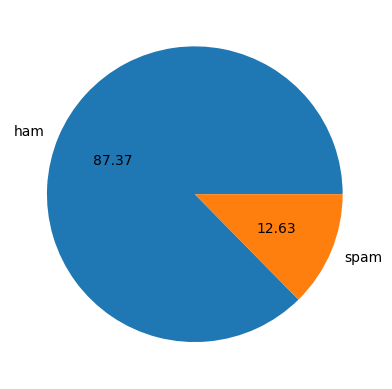

In [36]:
plt.pie(df['target'].value_counts(), labels=['ham' , 'spam'], autopct="%0.2f")
plt.show()

In [78]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ieish\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ieish\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ieish\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ieish\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ieish\AppData\Roaming\nltk_data...


True

In [39]:
df['num_char'] = df['text'].apply(len)

C:\Users\ieish\AppData\Local\Temp\ipykernel_25612\3778023891.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_char'] = df['text'].apply(len)


In [45]:
df['num_words']= df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

C:\Users\ieish\AppData\Local\Temp\ipykernel_25612\3620582556.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_words']= df['text'].apply(lambda x:len(nltk.word_tokenize(x)))


In [46]:
df['num_sentence']= df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

C:\Users\ieish\AppData\Local\Temp\ipykernel_25612\3709430826.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_sentence']= df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))


In [47]:
df

,target,text,num_char,num_words,num_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


In [49]:
df[['num_char','num_words','num_sentence']].describe()

,num_char,num_words,num_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
# ham analysis
df[df['target'] == 0][['num_char','num_words','num_sentence']].describe()

,num_char,num_words,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [51]:
# spam analysis
df[df['target'] ==  1][['num_char','num_words','num_sentence']].describe()

,num_char,num_words,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_char', ylabel='Count'>

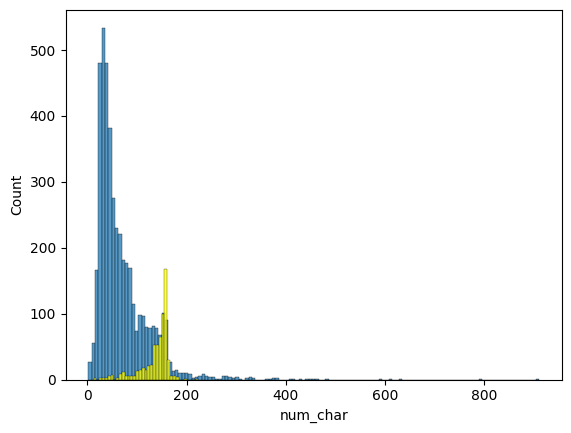

In [57]:
sns.histplot(df[df['target'] ==  0]['num_char'])
sns.histplot(df[df['target'] ==  1]['num_char'],color='yellow')

<Axes: xlabel='num_words', ylabel='Count'>

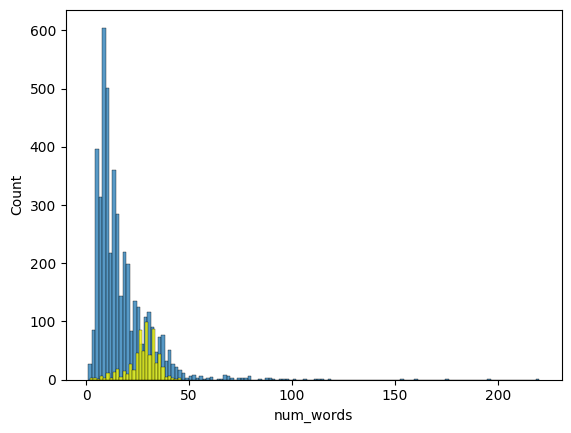

In [58]:
sns.histplot(df[df['target'] ==  0]['num_words'])
sns.histplot(df[df['target'] ==  1]['num_words'],color='yellow')

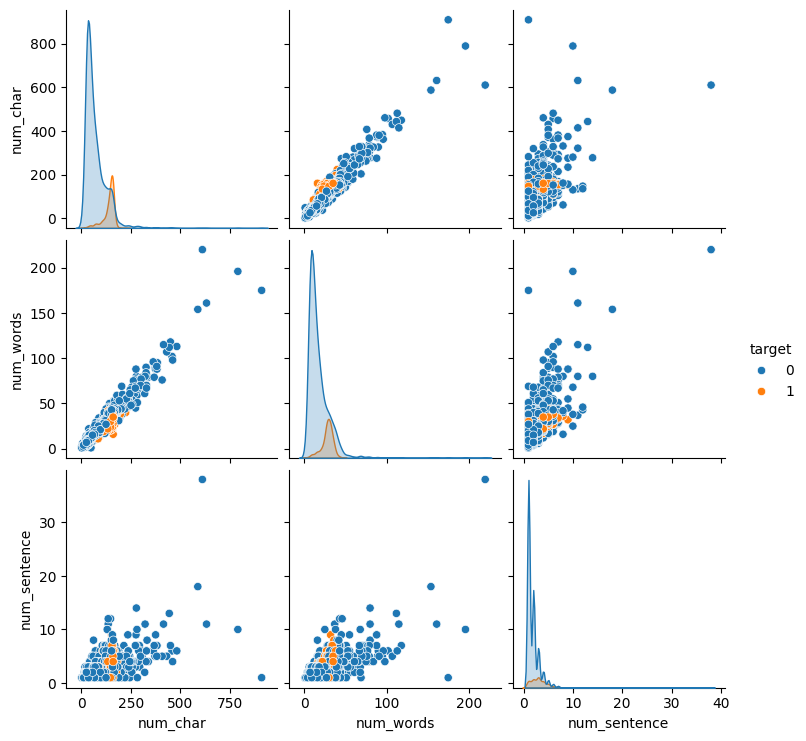

In [59]:
sns.pairplot(df,hue='target')

In [65]:
df.select_dtypes(include=['number']).corr()

,target,num_char,num_words,num_sentence
target,1.000000,0.384717,0.262912,0.263939
num_char,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentence,0.263939,0.624139,0.679971,1.000000


<Axes: >

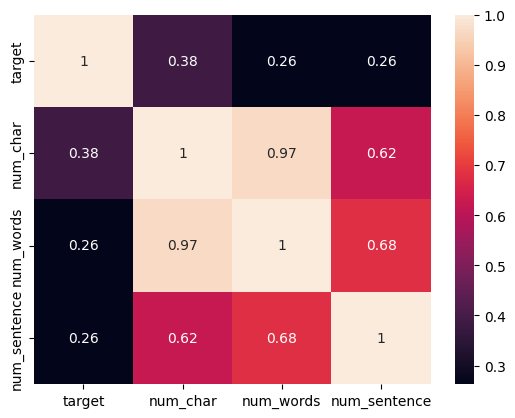

In [66]:
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True)

### Data Preprocessing
 - lower case 
 - tokenization 
 - removing special words 
 - removing stop words and puntuation 
 - stemming 

In [77]:
from nltk.corpus import stopwords
stopwords.words('english')

LookupError: 
**********************************************************************
  Resource 'stopwords' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('stopwords')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'corpora/stopwords'

  Searched in:
    - 'C:\\Users\\ieish/nltk_data'
    - 'c:\\Users\\ieish\\AppData\\Local\\Programs\\Python\\Python313\\nltk_data'
    - 'c:\\Users\\ieish\\AppData\\Local\\Programs\\Python\\Python313\\share\\nltk_data'
    - 'c:\\Users\\ieish\\AppData\\Local\\Programs\\Python\\Python313\\lib\\nltk_data'
    - 'C:\\Users\\ieish\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [73]:
def transform_text (text):
  text = text.lower()
  text = nltk.word_tokenize(text)
  y = []
  for i in text :
    if i.isalnum():
       y.append(i)
  return y

In [74]:
transform_text("Hey I am Ishan Kumar %% Tiwari")

['hey', 'i', 'am', 'ishan', 'kumar', 'tiwari']